# **Project Name**    -  `PhonePe Transaction Insights`

##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


`With the increasing reliance on digital payment systems like PhonePe, understanding the dynamics of transactions, user engagement, and insurance-related data is crucial for improving services and targeting users effectively. This project aims to analyze and visualize aggregated values of payment categories, create maps for total values at state and district levels, and identify top-performing states, districts, and pin codes.`

#### **Define Your Business Objective?**

Answer Here.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [21]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

### Dataset Loading

In [22]:
# Load Dataset
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="RRyy1234@$",
    database="phonepe_db"
)

query = "SELECT * FROM aggregated_transaction LIMIT 100000"
df = pd.read_sql(query, conn)

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\3730584713.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


### Dataset First View

In [23]:
# Dataset First Look
df.head()

,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,India,2018,1,Recharge & bill payments,72550406,1.447271e+10
1,India,2018,1,Peer-to-peer payments,46982705,1.472459e+11
2,India,2018,1,Merchant payments,5368669,4.656679e+09
3,India,2018,1,Financial Services,3762820,8.158531e+08
4,India,2018,1,Others,5761576,4.643217e+09


### Dataset Rows & Columns count

In [24]:
# Dataset Rows & Columns count
df.shape

(15522, 6)

### Dataset Information

In [25]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15522 entries, 0 to 15521
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               15522 non-null  object 
 1   year                15522 non-null  int64  
 2   quarter             15522 non-null  int64  
 3   transaction_type    15522 non-null  object 
 4   transaction_count   15522 non-null  int64  
 5   transaction_amount  15522 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 727.7+ KB


#### Duplicate Values

In [26]:
# Dataset Duplicate Value Count
print(df.duplicated(subset=["state", "year", "quarter", "transaction_type"]).sum())
df[df.duplicated()].head()

10348


,state,year,quarter,transaction_type,transaction_count,transaction_amount
5174,India,2018,1,Recharge & bill payments,72550406,1.447271e+10
5175,India,2018,1,Peer-to-peer payments,46982705,1.472459e+11
5176,India,2018,1,Merchant payments,5368669,4.656679e+09
5177,India,2018,1,Financial Services,3762820,8.158531e+08
5178,India,2018,1,Others,5761576,4.643217e+09


#### Missing Values/Null Values

In [27]:
# Missing Values/Null Values Count
df.isnull().sum()

state                 0
year                  0
quarter               0
transaction_type      0
transaction_count     0
transaction_amount    0
dtype: int64

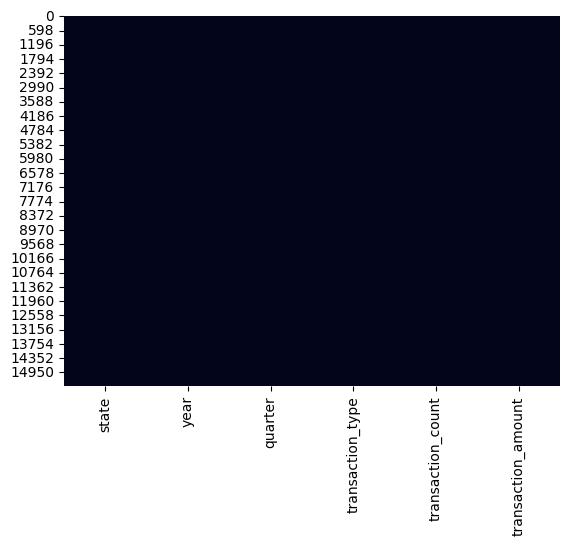

In [28]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)
plt.show()

### What did you know about your dataset?

The dataset represents aggregated transaction data from PhonePe across different states in India, segmented by year, quarter, and transaction categories. Each record captures the number of transactions and the corresponding transaction amount for a specific transaction type such as peer-to-peer payments, merchant payments, and recharge & bill payments.

The data is structured at a granular level defined by the combination of state, year, quarter, and transaction type, enabling detailed temporal and categorical analysis of transaction behavior.

Initial exploration reveals that the dataset is well-structured with clearly defined numerical and categorical fields. However, the presence of duplicate records suggests potential redundancy introduced during data ingestion or aggregation, which needs to be addressed during the data cleaning phase.

The dataset does not exhibit significant missing values, indicating reliable data collection. Overall, the dataset is suitable for performing trend analysis, regional comparisons, and category-wise transaction behavior studies.

The dataset includes two key numerical features: transaction_count and transaction_amount.

- transaction_count represents the total number of transactions performed for a given state, time period, and transaction category.

- transaction_amount captures the total monetary value of those transactions.

Together, these features provide insights into both the volume and value of transactions, enabling a deeper understanding of user activity patterns. For instance, a high transaction count with relatively low transaction amount may indicate frequent low-value payments (e.g., recharges), whereas a lower count with high transaction value may indicate high-value transfers.

## ***2. Understanding Your Variables***

In [29]:
# Dataset Columns
print("Total Columns:", len(df.columns))
print("\nColumn Names:")
for col in df.columns:
    print("-", col)

Total Columns: 6

Column Names:
- state
- year
- quarter
- transaction_type
- transaction_count
- transaction_amount


In [30]:
# Dataset Describe
df.describe(include='all')

,state,year,quarter,transaction_type,transaction_count,transaction_amount
count,15522,15522.000000,15522.000000,15522,1.552200e+04,1.552200e+04
unique,37,NaN,NaN,5,NaN,NaN
top,India,NaN,NaN,Recharge & bill payments,NaN,NaN
freq,420,NaN,NaN,3108,NaN,NaN
mean,NaN,2021.002513,2.500773,NaN,9.094881e+07,1.335613e+11
std,NaN,1.999725,1.118070,NaN,6.254310e+08,1.002260e+12
min,NaN,2018.000000,1.000000,NaN,2.000000e+00,3.439721e+01
25%,NaN,2019.000000,2.000000,NaN,6.361600e+04,4.420255e+07
50%,NaN,2021.000000,3.000000,NaN,5.737635e+05,4.846731e+08
75%,NaN,2023.000000,4.000000,NaN,1.363107e+07,1.255459e+10


### Variables Description

### 📊 Data Dictionary

| Variable Name         | Description                                                                 | Data Type |
|----------------------|-----------------------------------------------------------------------------|----------|
| state                | Represents the geographic region (state or country level - e.g., India)    | Categorical (String) |
| year                 | Indicates the year in which the transaction occurred                        | Integer |
| quarter              | Represents the quarter of the year (1 to 4)                                 | Integer |
| transaction_type     | Type/category of transaction (e.g., P2P, Merchant, Recharge, etc.)         | Categorical (String) |
| transaction_count    | Total number of transactions for the given state, time period, and type    | Integer |
| transaction_amount   | Total monetary value of transactions for the given state, time period      | Float |

### Check Unique Values for each variable.

In [31]:
# Check Unique Values for each variable.
unique_counts = df.nunique().reset_index()
unique_counts.columns = ['Column', 'Unique Values']
unique_counts.sort_values(by='Unique Values', ascending=False)

,Column,Unique Values
5,transaction_amount,5174
4,transaction_count,5106
0,state,37
1,year,7
3,transaction_type,5
2,quarter,4


## 3. ***Data Wrangling***

### Data Wrangling Code

In [48]:
# Write your code to make your dataset analysis ready.
print("duplicate rows", df.duplicated(subset=["state", "year", "quarter", "transaction_type"]).sum())
df = df.drop_duplicates(subset=["state", "year", "quarter", "transaction_type"])
print("verify removal -> ", df.duplicated(subset=["state", "year", "quarter", "transaction_type"]).sum())

print(df.dtypes)

duplicate rows 0
verify removal ->  0
state                  object
year                    int64
quarter                 int64
transaction_type       object
transaction_count       int64
transaction_amount    float64
dtype: object


### What all manipulations have you done and insights you found?

### Data Wrangling

The dataset was examined for inconsistencies and redundancies before analysis.

Duplicate records were identified based on the combination of state, year, quarter, and transaction type, which represents the natural granularity of the dataset. These duplicates were removed to prevent double counting and ensure accurate aggregation.

The dataset was further checked for missing values, and no significant null values were found, indicating a well-structured dataset.

Data types of all variables were verified and found to be appropriate for analysis. Overall, minimal preprocessing was required, allowing the dataset to be directly used for exploratory data analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\2705175345.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trend = pd.read_sql(query, conn)


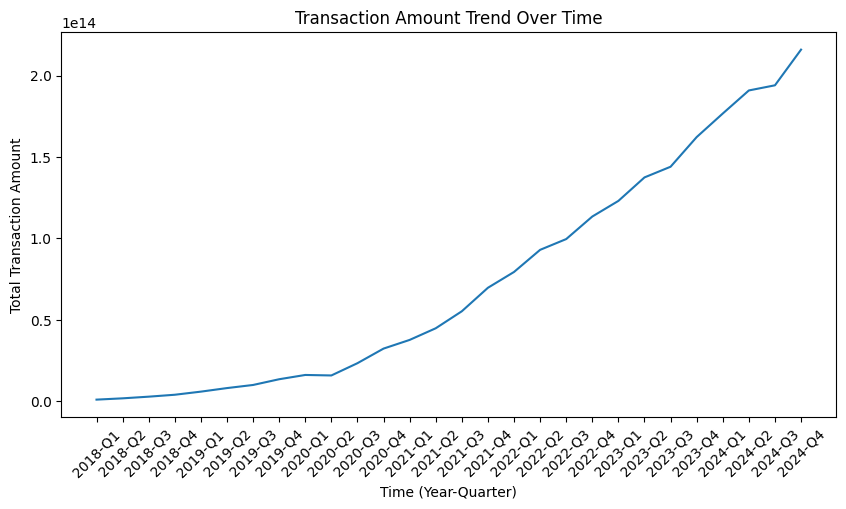

In [49]:
# Chart - 1 -> Transaction Trends Over Time
query = """
SELECT year, quarter, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY year, quarter
ORDER BY year, quarter
"""
df_trend = pd.read_sql(query, conn)

df_trend["time"] = df_trend["year"].astype(str) + "-Q" + df_trend["quarter"].astype(str)

plt.figure(figsize=(10,5))
plt.plot(df_trend["time"], df_trend["total_amount"])
plt.xticks(rotation=45)
plt.title("Transaction Amount Trend Over Time")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Total Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen to analyze transaction trends over time, as it effectively captures temporal patterns and highlights growth trajectories across quarters. This visualization helps in identifying long-term trends, seasonal variations, and sudden spikes or drops in transaction activity.

##### 2. What is/are the insight(s) found from the chart?

The transaction amount exhibits a strong and consistent upward trend from 2018 to 2024, indicating rapid adoption of digital payments on the platform.

There is a noticeable acceleration in growth post-2020, which may be attributed to increased digital adoption during and after the COVID-19 period.

Periodic spikes in certain quarters suggest seasonal effects, likely driven by festive periods and higher consumer spending cycles.

Overall, the platform demonstrates sustained growth, reflecting increasing user trust and expanding transaction volume over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights indicate that PhonePe is experiencing strong growth in digital transaction adoption, which supports continued investment in infrastructure and scalability.

Seasonal spikes suggest opportunities for targeted marketing campaigns and promotional offers during high-activity periods to further boost transactions.

The consistent upward trend also validates expansion strategies and encourages deeper penetration into emerging markets to sustain long-term growth.

#### Chart - 2

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\972709889.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_state = pd.read_sql(query, conn)


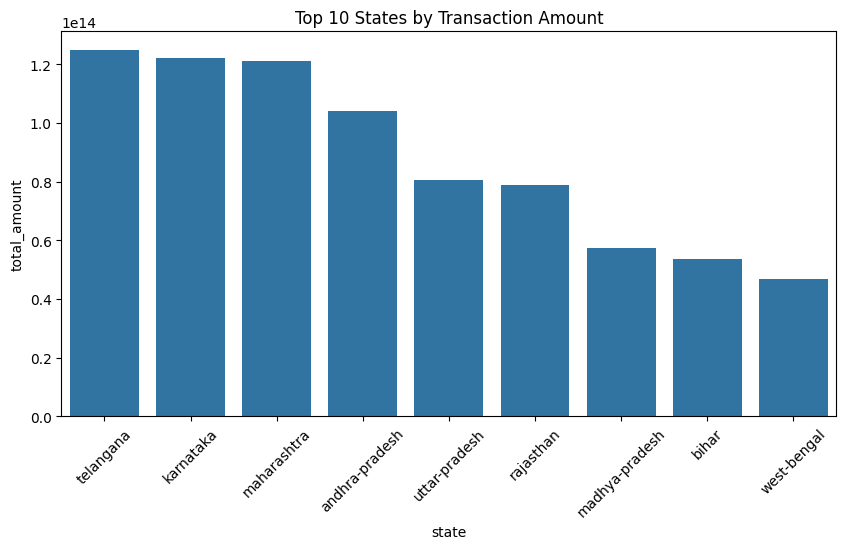

In [57]:
# Chart - 2 -> State-wise Transaction Comparison
query = """
SELECT state, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10
"""
df_state = pd.read_sql(query, conn)
df_state = df_state[df_state["state"] != "India"]

plt.figure(figsize=(10,5))
sns.barplot(data=df_state, x="state", y="total_amount")
plt.xticks(rotation=45)
plt.title("Top 10 States by Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used to compare transaction amounts across different states, as it provides a clear visual representation of relative performance. This helps in identifying top-performing regions and understanding geographical distribution of transaction activity.

##### 2. What is/are the insight(s) found from the chart?

A significant concentration of transaction volume is observed in a few states, states like Telangana, Karnataka, and Maharashtra.

These states likely represent regions with higher digital penetration, better infrastructure, and stronger user adoption of digital payment systems.

In contrast, lower-ranked states contribute comparatively less, indicating potential gaps in adoption and user engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High-performing states can be leveraged as benchmark markets to understand successful adoption strategies and replicate them in lower-performing regions.

States with lower transaction volumes present strong opportunities for expansion through targeted awareness campaigns, partnerships, and localized strategies.

This insight enables data-driven allocation of resources, focusing on both strengthening dominant markets and unlocking growth in underpenetrated regions.

#### Chart - 3

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\210167374.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_device = pd.read_sql(query, conn)


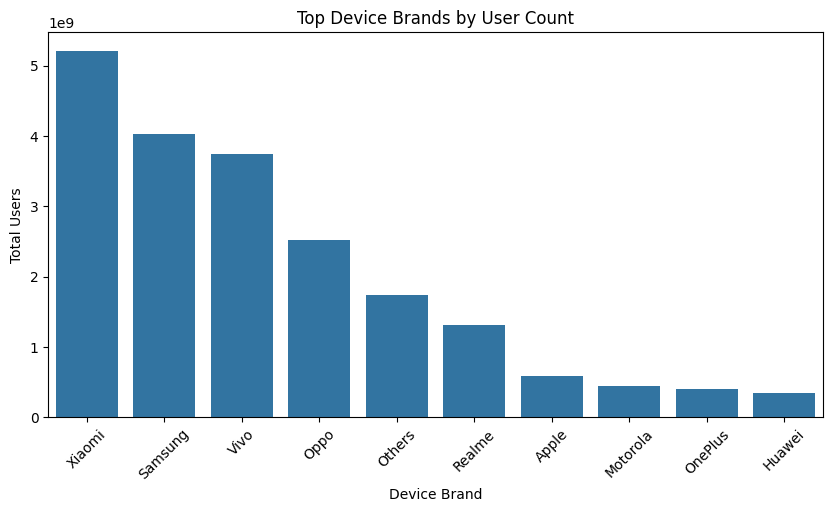

In [52]:
# Chart - 3 -> Device Brand Popularity
query = """
SELECT brand, SUM(user_count) AS total_users
FROM aggregated_user
GROUP BY brand
ORDER BY total_users DESC
LIMIT 10
"""
df_device = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_device, x="brand", y="total_users")
plt.xticks(rotation=45)
plt.title("Top Device Brands by User Count")
plt.xlabel("Device Brand")
plt.ylabel("Total Users")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare user distribution across different device brands, as it clearly highlights dominant players and relative differences in user base. This visualization helps in identifying which device ecosystems contribute most to the platform's user base.

##### 2. What is/are the insight(s) found from the chart?

The user base is heavily concentrated among a few dominant device brands, indicating a skewed distribution of users across the smartphone ecosystem.

Brands like Xiaomi, Samsung, and Vivo are likely leading contributors, reflecting the dominance of affordable Android devices in the market.

The presence of a long tail of smaller brands suggests fragmented usage but relatively low contribution to total users.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding device dominance helps in optimizing app performance for the most widely used devices, ensuring better user experience for the majority of users.

It also enables targeted partnerships with dominant device manufacturers for pre-installation or promotional strategies.

Additionally, insights into device distribution can guide testing, optimization, and feature prioritization for maximum impact.

#### Chart - 4

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\1598551686.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_engagement = pd.read_sql(query, conn)


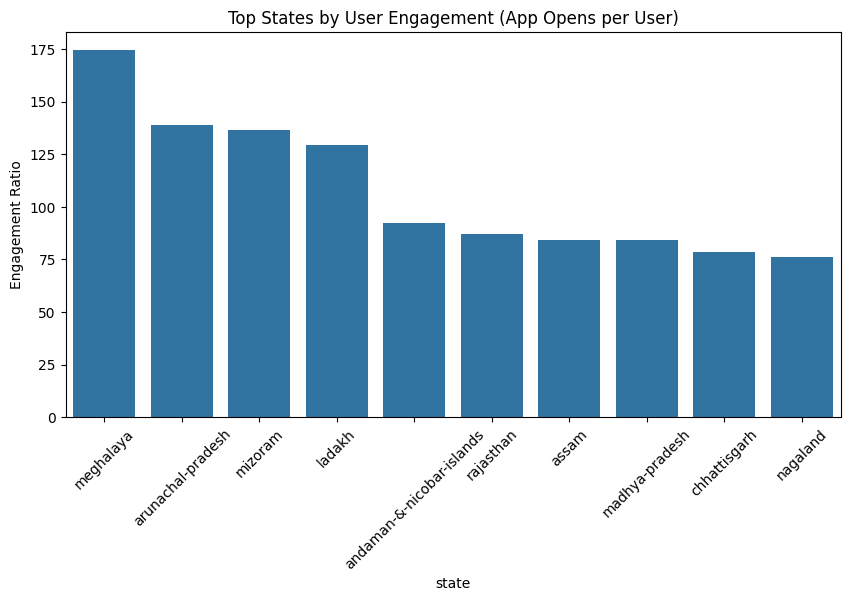

In [53]:
# Chart - 4 -> User Engagement Analysis
query = """
SELECT state,
       SUM(registered_users) AS users,
       SUM(app_opens) AS opens
FROM map_user
GROUP BY state
"""
df_engagement = pd.read_sql(query, conn)
df_engagement["engagement_ratio"] = df_engagement["opens"] / df_engagement["users"]

plt.figure(figsize=(10,5))
sns.barplot(data=df_engagement.sort_values(by="engagement_ratio", ascending=False).head(10),
            x="state", y="engagement_ratio")
plt.xticks(rotation=45)
plt.title("Top States by User Engagement (App Opens per User)")
plt.ylabel("Engagement Ratio")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare user engagement across different states using the engagement ratio (app opens per user). This metric normalizes user activity by accounting for differences in user base size, enabling a more accurate comparison of how actively users interact with the platform across regions.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals significant variation in user engagement across states, with regions like Meghalaya, Arunachal Pradesh, and Mizoram showing notably high engagement ratios.

These states, despite having smaller user bases, demonstrate highly active users, indicating strong behavioral engagement and frequent app usage.

In contrast, other states exhibit relatively lower engagement ratios, suggesting that while users are registered, they may not be consistently interacting with the platform.

This disparity highlights that high user acquisition does not necessarily translate into high user activity, emphasizing the importance of engagement-focused strategies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High-engagement states represent valuable markets with strong user retention and can serve as benchmarks for understanding successful engagement drivers.

Low-engagement regions present an opportunity for targeted interventions such as personalized notifications, feature enhancements, or localized campaigns to increase user activity.

By focusing on improving engagement rather than just expanding the user base, PhonePe can enhance customer lifetime value, improve retention rates, and drive more consistent transaction activity across all regions.

#### Chart - 5

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\4109622850.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ins_trend = pd.read_sql(query, conn)


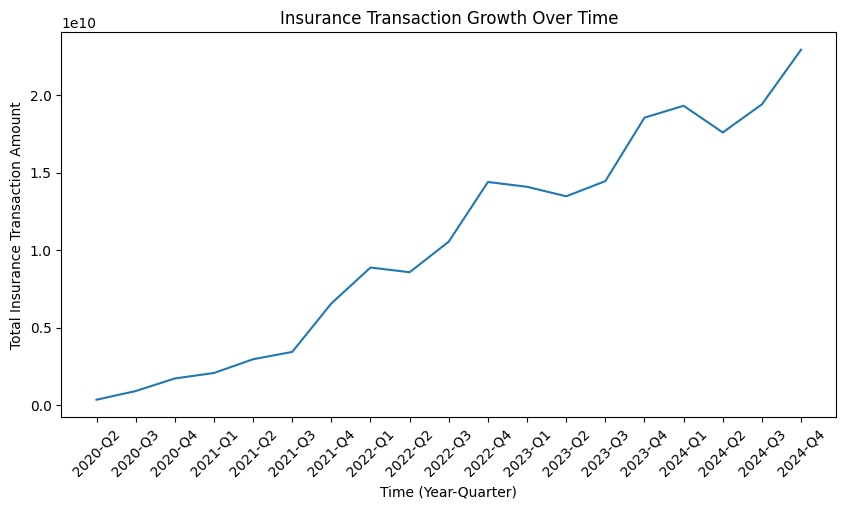

In [54]:
# Chart - 5 -> Insurance Transaction Trends
query = """
SELECT year, quarter, SUM(transaction_amount) AS total_amount
FROM aggregated_insurance
GROUP BY year, quarter
ORDER BY year, quarter
"""
df_ins_trend = pd.read_sql(query, conn)
df_ins_trend["time"] = df_ins_trend["year"].astype(str) + "-Q" + df_ins_trend["quarter"].astype(str)

plt.figure(figsize=(10,5))
plt.plot(df_ins_trend["time"], df_ins_trend["total_amount"])
plt.xticks(rotation=45)
plt.title("Insurance Transaction Growth Over Time")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Total Insurance Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used to analyze the growth trend of insurance transactions over time, as it effectively captures temporal changes and highlights adoption patterns across different periods.

##### 2. What is/are the insight(s) found from the chart?

The insurance transaction volume shows a gradual upward trend over time, indicating increasing adoption of insurance services on the platform.

Compared to general transaction growth, the rise in insurance transactions appears more recent and less steep, suggesting that this segment is still in an early growth phase.

The steady increase reflects growing user awareness and trust in digital insurance offerings, but also highlights significant untapped potential for expansion.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The upward trend in insurance transactions indicates a promising growth opportunity for PhonePe to expand its presence in the insurance domain.

Since adoption is still emerging, targeted marketing campaigns, partnerships with insurance providers, and user education initiatives can significantly accelerate growth.

Focusing on this segment can diversify revenue streams and strengthen PhonePe’s position as a comprehensive financial services platform.

#### Chart - 6

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\2401790834.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ins_state = pd.read_sql(query, conn)


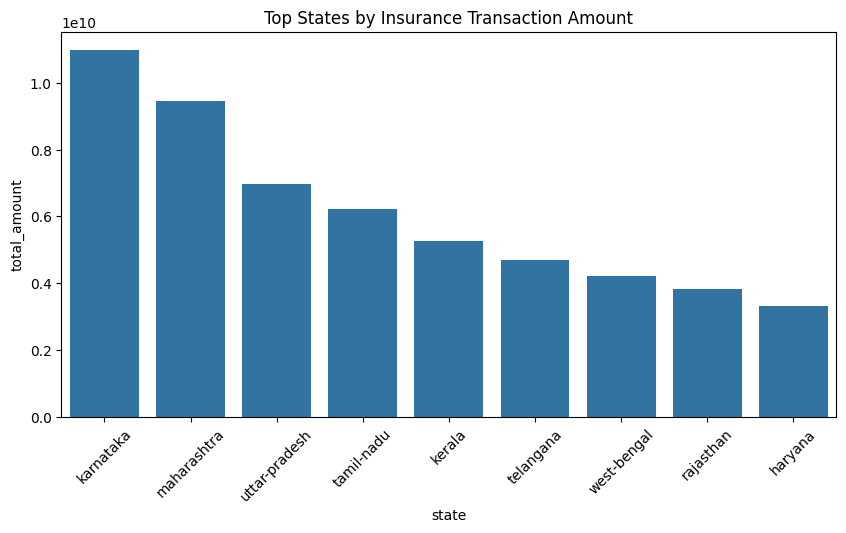

In [56]:
# Chart - 6 -> Insurance Transaction by State
query = """
SELECT state, SUM(transaction_amount) AS total_amount
FROM aggregated_insurance
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10
"""
df_ins_state = pd.read_sql(query, conn)
df_ins_state = df_ins_state[df_ins_state["state"] != "India"]

plt.figure(figsize=(10,5))
sns.barplot(data=df_ins_state, x="state", y="total_amount")
plt.xticks(rotation=45)
plt.title("Top States by Insurance Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare insurance transaction amounts across different states, as it clearly highlights regional variations in adoption. This visualization helps identify leading states and understand how insurance usage is distributed geographically.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that insurance transaction activity is concentrated in a few key states such as Karnataka and Maharashtra, indicating higher adoption in these regions.

These states likely have better digital awareness, stronger financial ecosystems, and higher user trust in online insurance services.

In contrast, many other states show relatively lower transaction volumes, suggesting that insurance adoption is still limited and uneven across the country.

Overall, the distribution indicates that while some regions are mature in insurance usage, a large portion of the market remains underpenetrated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The concentration of insurance transactions in a few states highlights an opportunity to replicate successful strategies from high-performing regions into underperforming ones.

Low-adoption states present significant growth potential, where targeted awareness campaigns, simplified onboarding, and localized offerings can drive higher adoption.

By focusing on expanding insurance penetration in emerging regions, PhonePe can unlock new revenue streams and strengthen its position in the digital financial services ecosystem.

#### Chart - 7

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\3387972084.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_type = pd.read_sql(query, conn)


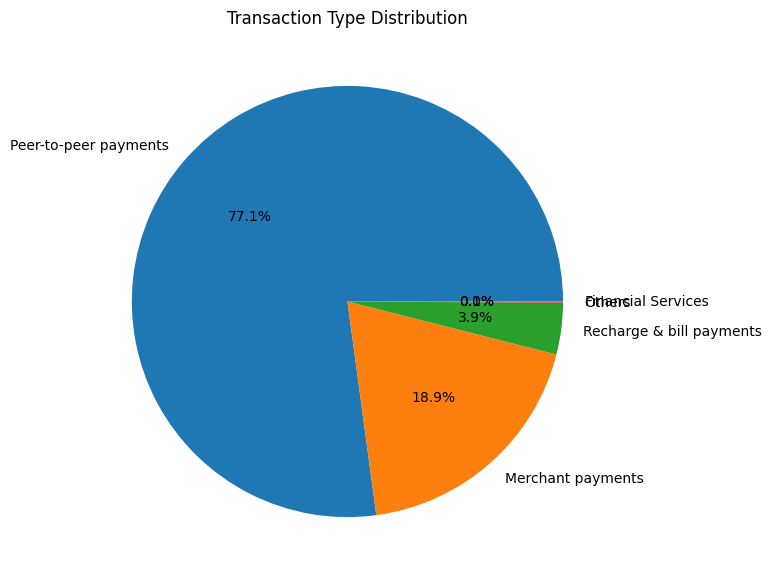

In [ ]:
# Chart - 7 -> Transaction Type Distribution
query = """
SELECT transaction_type, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY transaction_type
ORDER BY total_amount DESC
"""
df_type = pd.read_sql(query, conn)

plt.figure(figsize=(7,7))
plt.pie(df_type["total_amount"], labels=df_type["transaction_type"], autopct='%1.1f%%')
plt.title("Transaction Type Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\150151308.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_compare = pd.read_sql(query, conn)


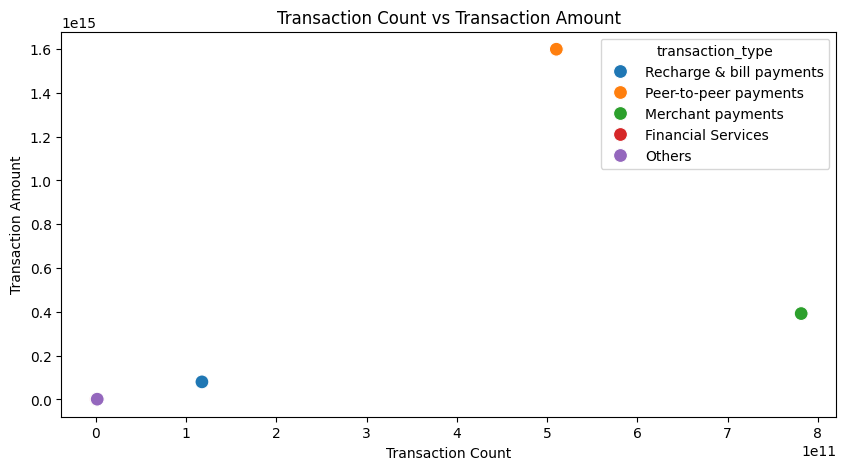

In [59]:
# Chart - 8 -> Transaction count vs Amount by Transaction Type
query = """
SELECT transaction_type,
       SUM(transaction_count) AS total_count,
       SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY transaction_type
"""
df_compare = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.scatterplot(data=df_compare, x="total_count", y="total_amount", hue="transaction_type", s=100)
plt.title("Transaction Count vs Transaction Amount")
plt.xlabel("Transaction Count")
plt.ylabel("Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\4132825759.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_district = pd.read_sql(query, conn)


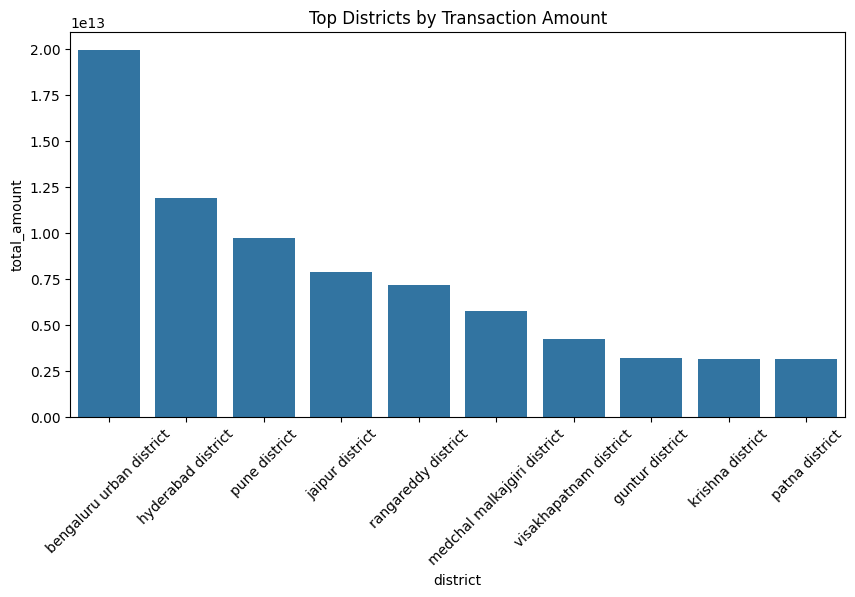

In [60]:
# Chart - 9 -> District-wise Transaction Analysis
query = """
SELECT district, SUM(transaction_amount) AS total_amount
FROM map_transaction
GROUP BY district
ORDER BY total_amount DESC
LIMIT 10
"""
df_district = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_district, x="district", y="total_amount")
plt.xticks(rotation=45)
plt.title("Top Districts by Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

C:\Users\rupes\AppData\Local\Temp\ipykernel_2424\3805709072.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_user_growth = pd.read_sql(query, conn)


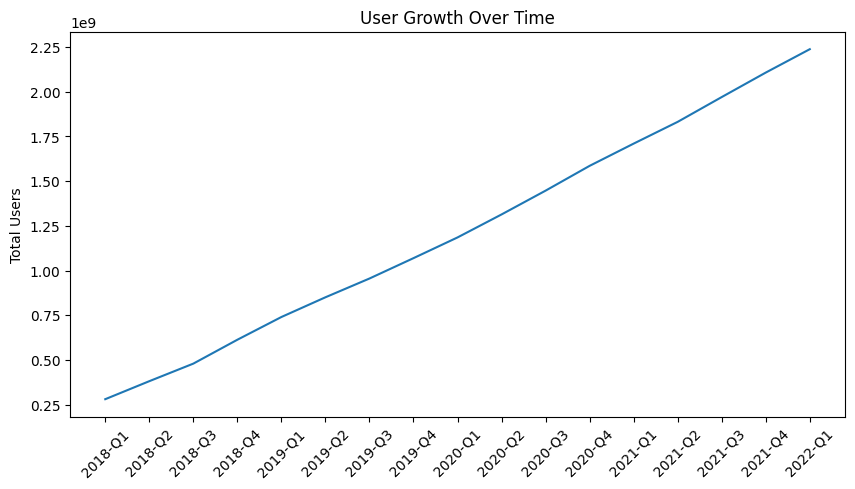

In [63]:
# Chart - 10 -> User Growth Over Time
query = """
SELECT year, quarter, SUM(user_count) AS users
FROM aggregated_user
GROUP BY year, quarter
ORDER BY year, quarter
"""
df_user_growth = pd.read_sql(query, conn)
df_user_growth["time"] = df_user_growth["year"].astype(str) + "-Q" + df_user_growth["quarter"].astype(str)

plt.figure(figsize=(10,5))
plt.plot(df_user_growth["time"], df_user_growth["users"])
plt.xticks(rotation=45)
plt.title("User Growth Over Time")
plt.ylabel("Total Users")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.